# Exploratory Data Analysis (EDA)
Notebook version of `EDA.py`.

In [1]:
# Step 1. Load the Master Dataset
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("master_dataset.csv")
df.head()

,order_id,product_id,add_to_cart_order,reordered,user_id,order_number,order_dow,order_hour_of_day,days_since_prior_order,product_name,aisle_id,department_id,aisle,department
0,2,33120,1.0,1.0,202279,3,5,9,8,Organic Egg Whites,86,16,eggs,dairy eggs
1,2,28985,2.0,1.0,202279,3,5,9,8,Michigan Organic Kale,83,4,fresh vegetables,produce
2,2,9327,3.0,0.0,202279,3,5,9,8,Garlic Powder,104,13,spices seasonings,pantry
3,2,45918,4.0,1.0,202279,3,5,9,8,Coconut Butter,19,13,oils vinegars,pantry
4,2,30035,5.0,0.0,202279,3,5,9,8,Natural Sweetener,17,13,baking ingredients,pantry


# Step 2. Customer Ordering Patterns

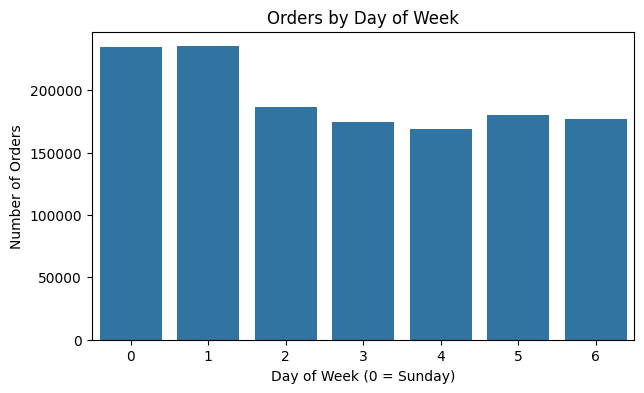

In [2]:
## Orders by Day of Week
orders_dow = df.groupby("order_dow")["order_id"].nunique()

plt.figure(figsize=(7,4))
sns.barplot(x=orders_dow.index, y=orders_dow.values)
plt.title("Orders by Day of Week")
plt.xlabel("Day of Week (0 = Sunday)")
plt.ylabel("Number of Orders")
plt.show()

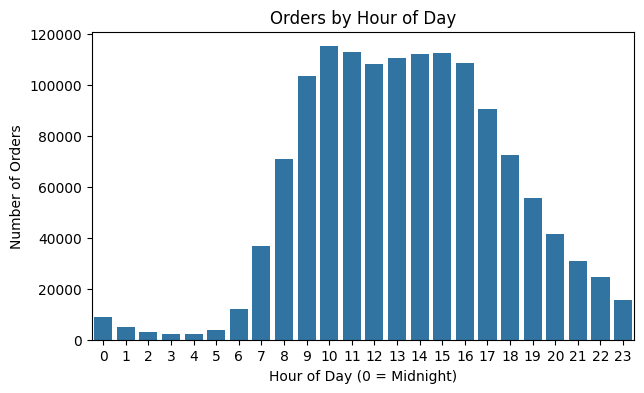

In [3]:
## Orders by Hour of Day
orders_hour = df.groupby("order_hour_of_day")["order_id"].nunique()

plt.figure(figsize=(7,4))
sns.barplot(x=orders_hour.index, y=orders_hour.values)
plt.title("Orders by Hour of Day")
plt.xlabel("Hour of Day (0 = Midnight)")
plt.ylabel("Number of Orders")
plt.show()

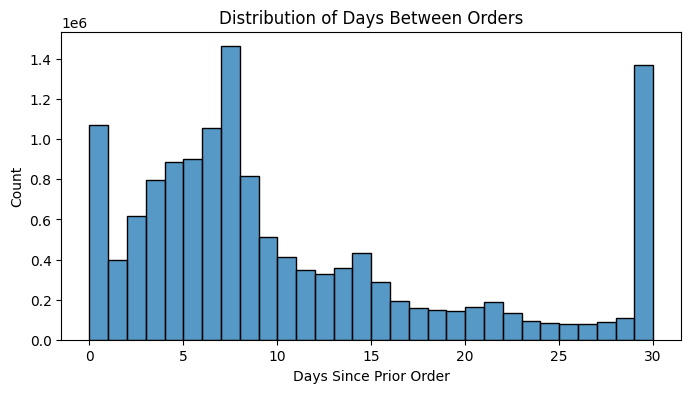

In [4]:
## Time between Orders
plt.figure(figsize=(8,4))
sns.histplot(df["days_since_prior_order"], bins=30, kde=False)
plt.title("Distribution of Days Between Orders")
plt.xlabel("Days Since Prior Order")
plt.ylabel("Count")
plt.show()

# Step 3. Reorder Behavior

In [5]:
## Overall Reorder Rate
overall_rate = df["reordered"].mean()
print(f"Overall Reorder Rate: {overall_rate:.2%}")

Overall Reorder Rate: 58.96%


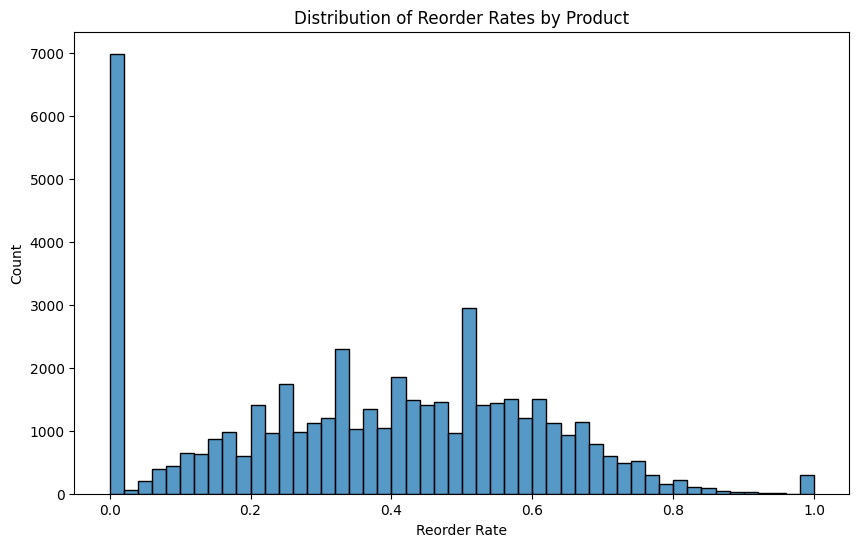

In [6]:
## Reorder Rate by Product
reorder_rate_product = df.groupby("product_id")["reordered"].mean().sort_values()

plt.figure(figsize=(10,6))
sns.histplot(reorder_rate_product, bins=50, kde=False)
plt.title("Distribution of Reorder Rates by Product")
plt.xlabel("Reorder Rate")
plt.ylabel("Count")
plt.show()

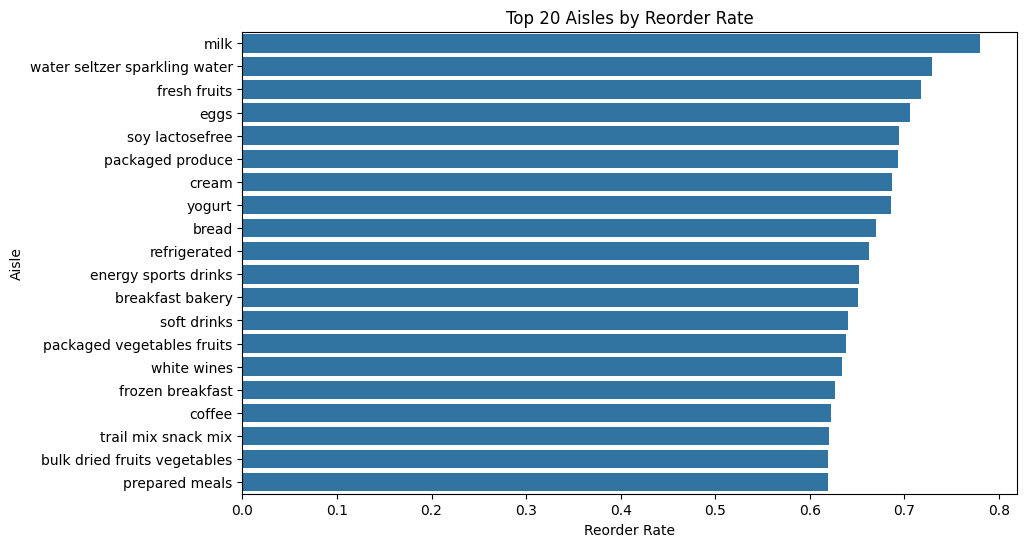

In [7]:
## Reorder Rate by Aisle
reorder_rate_aisle = df.groupby("aisle")["reordered"].mean().sort_values(ascending=False).head(20)

plt.figure(figsize=(10,6))
sns.barplot(x=reorder_rate_aisle.values, y=reorder_rate_aisle.index)
plt.title("Top 20 Aisles by Reorder Rate")
plt.xlabel("Reorder Rate")
plt.ylabel("Aisle")
plt.show()

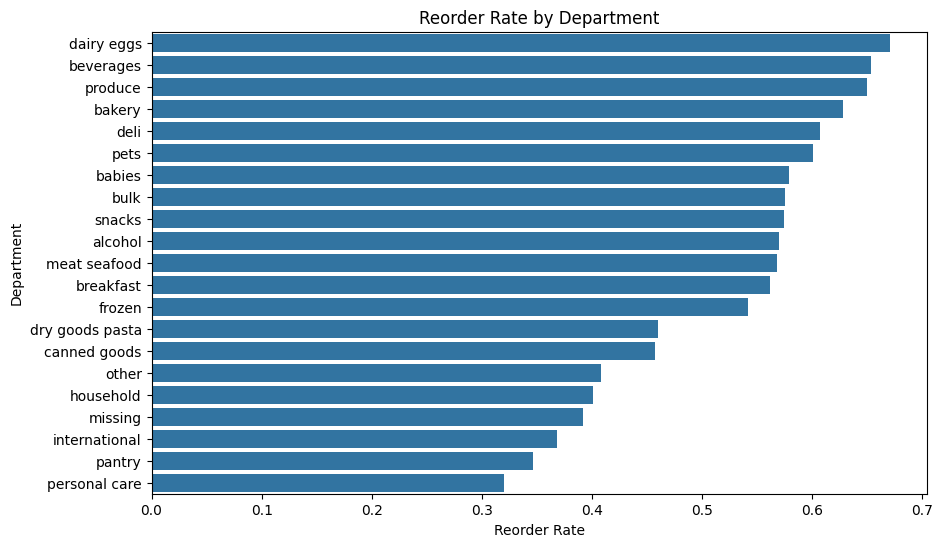

In [8]:
## Reorder Rate by Department
dept_reorder_rate = df.groupby("department")["reordered"].mean().sort_values(ascending=False)
dept_reorder_rate.head(10)

plt.figure(figsize=(10,6))
sns.barplot(x=dept_reorder_rate.values, y=dept_reorder_rate.index)
plt.title("Reorder Rate by Department")
plt.xlabel("Reorder Rate")
plt.ylabel("Department")
plt.show()

# Step 4. Bestsellers

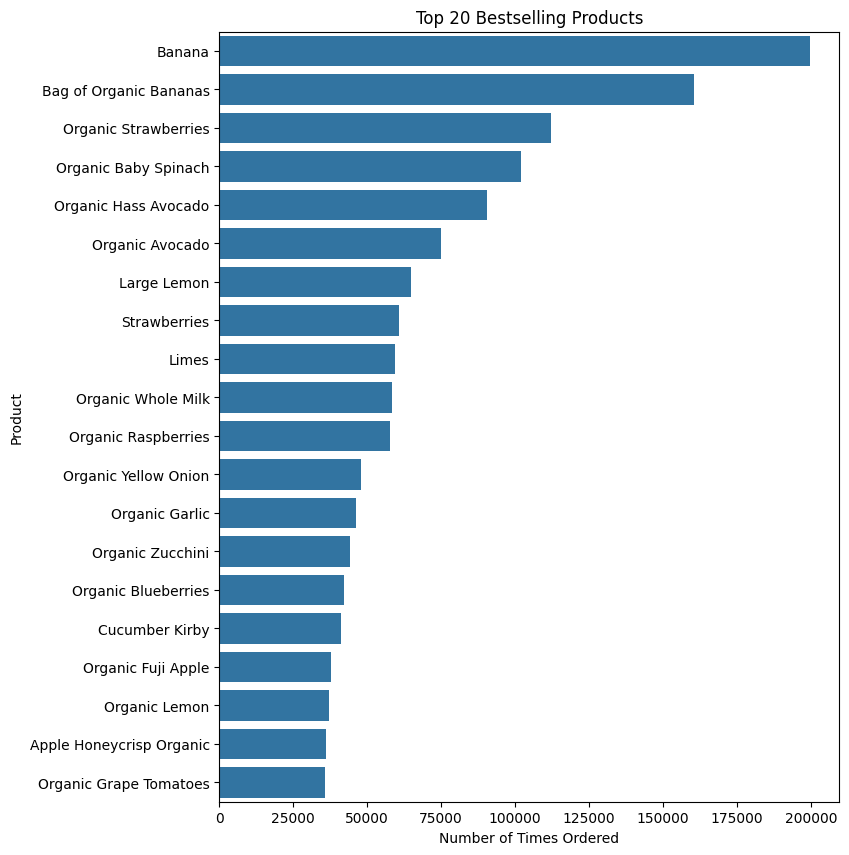

In [9]:
## Top 20 Products
top_products = df["product_name"].value_counts().head(20)

plt.figure(figsize=(8,10))
sns.barplot(y=top_products.index, x=top_products.values)
plt.title("Top 20 Bestselling Products")
plt.xlabel("Number of Times Ordered")
plt.ylabel("Product")
plt.show()

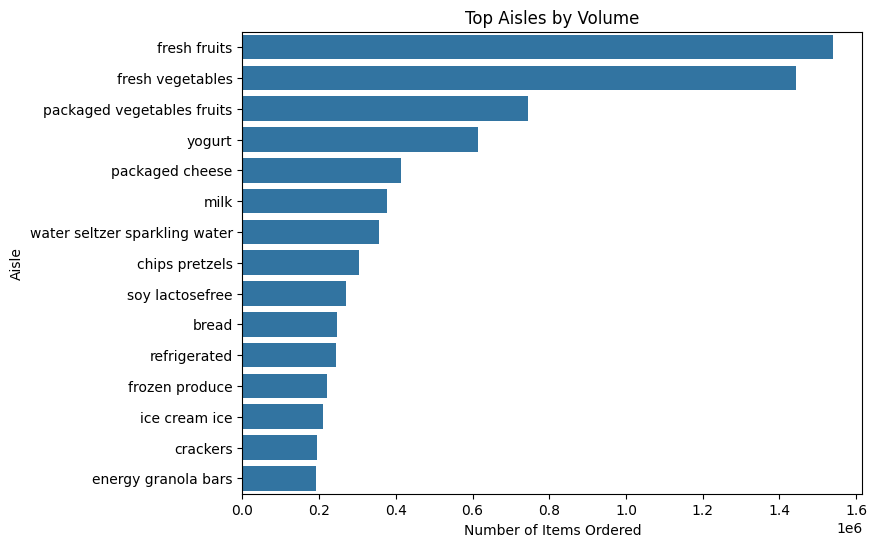

In [10]:
## Top Aisles
top_aisles = df["aisle"].value_counts().head(15)

plt.figure(figsize=(8,6))
sns.barplot(y=top_aisles.index, x=top_aisles.values)
plt.title("Top Aisles by Volume")
plt.xlabel("Number of Items Ordered")
plt.ylabel("Aisle")
plt.show()

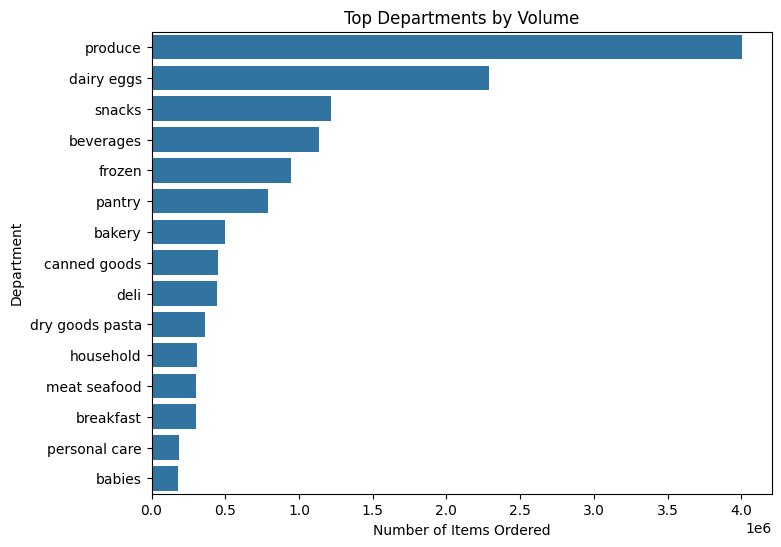

In [11]:
## Top Departments
top_depts = df["department"].value_counts().head(15)

plt.figure(figsize=(8,6))
sns.barplot(y=top_depts.index, x=top_depts.values)
plt.title("Top Departments by Volume")
plt.xlabel("Number of Items Ordered")
plt.ylabel("Department")
plt.show()

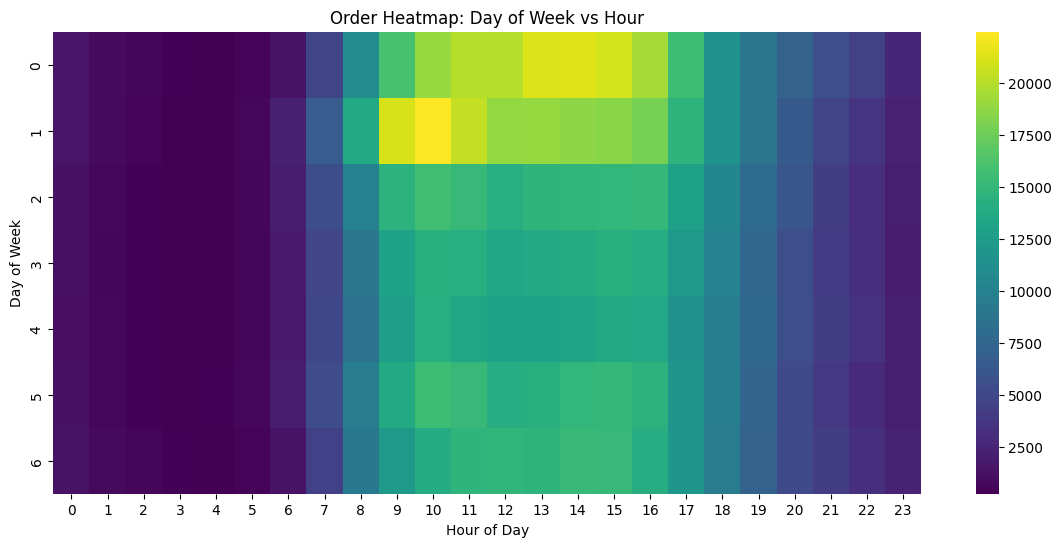

In [12]:
## Heatmap: Hour x Day Behavior
pivot = df.pivot_table(
    index="order_dow",
    columns="order_hour_of_day",
    values="order_id",
    aggfunc="nunique"
)

plt.figure(figsize=(14,6))
sns.heatmap(pivot, cmap="viridis")
plt.title("Order Heatmap: Day of Week vs Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Day of Week")
plt.show()